# 03. Section II reproduction: OU-Binomial temporal renormalization

This notebook is based on the original Section II analysis notebook used for the paper.
Only the data-input layer is adapted: it reads the k-month coarse-grained CSV produced by `02.ipynb` (`./pdata/SP_monthly_ALL_kmonth.csv`).
The OU-Binomial PyMC model, posterior-path survival coarse-graining, variance decomposition, ACF diagnostics, effective-mixing diagnostics, and KL projection diagnostics are kept in the same workflow as the original notebook.

Run order: `02.ipynb` -> `03.ipynb`.


In [1]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, skew, kurtosis

warnings.filterwarnings("ignore")

SEED = 123
rng = np.random.default_rng(SEED)

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
FIG_DIR = Path("./figures")

PDATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

K_LIST = [1, 2, 3, 4, 6, 12]
TARGET_SOURCE = "SP"
TARGET_SECTOR = "ALL"

P_MIN = 1e-10
P_MAX = 1.0 - 1e-10
EPS = 1e-12

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def clip_prob(p, p_min=P_MIN, p_max=P_MAX):
    return np.clip(np.asarray(p, dtype=float), p_min, p_max)


def probit(p):
    return norm.ppf(clip_prob(p))


def check_required_columns(df, required, df_name="df"):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing columns: {missing}")
    return True


def summarize_quantiles(values):
    values = np.asarray(values, dtype=float)
    return {
        "hdi_2.5%": np.nanquantile(values, 0.025),
        "median": np.nanquantile(values, 0.50),
        "hdi_97.5%": np.nanquantile(values, 0.975),
    }


## 1. Load and prepare monthly data

In [2]:
# ============================================================
# 1. Load k-month aggregated data and prepare k=1 monthly ALL data
# ============================================================

kmonth_path = PDATA_DIR / "SP_monthly_ALL_kmonth.csv"
df_kmonth = pd.read_csv(kmonth_path)

rename_map = {}
if "defaults" in df_kmonth.columns and "L" not in df_kmonth.columns:
    rename_map["defaults"] = "L"
if "default_count" in df_kmonth.columns and "L" not in df_kmonth.columns:
    rename_map["default_count"] = "L"
if "bonds" in df_kmonth.columns and "n" not in df_kmonth.columns:
    rename_map["bonds"] = "n"
if "N" in df_kmonth.columns and "n" not in df_kmonth.columns:
    rename_map["N"] = "n"

df_kmonth = df_kmonth.rename(columns=rename_map).copy()
check_required_columns(df_kmonth, ["k_month", "n", "L"], df_name="df_kmonth")

date_col = None
for c in ["date", "start_date", "block_start", "month"]:
    if c in df_kmonth.columns:
        date_col = c
        break

df_k1 = df_kmonth[df_kmonth["k_month"] == 1].copy()

if "source" in df_k1.columns:
    df_k1 = df_k1[df_k1["source"] == TARGET_SOURCE].copy()
if "sector" in df_k1.columns:
    df_k1 = df_k1[df_k1["sector"] == TARGET_SECTOR].copy()

if date_col is not None:
    df_k1[date_col] = pd.to_datetime(df_k1[date_col])
    df_k1 = df_k1.sort_values(date_col).reset_index(drop=True)
else:
    df_k1 = df_k1.reset_index(drop=True)

df_k1["n"] = df_k1["n"].astype(int)
df_k1["L"] = df_k1["L"].astype(int)
df_k1 = df_k1[(df_k1["n"] > 0) & (df_k1["L"] >= 0) & (df_k1["L"] <= df_k1["n"])].reset_index(drop=True)
df_k1["default_rate"] = df_k1["L"] / df_k1["n"]

T = len(df_k1)
n_obs = df_k1["n"].to_numpy(dtype=int)
L_obs = df_k1["L"].to_numpy(dtype=int)
r_obs = df_k1["default_rate"].to_numpy(dtype=float)

mean_rate = float(np.clip(np.sum(L_obs) / np.sum(n_obs), P_MIN, P_MAX))
mu_init = float(norm.ppf(mean_rate))

print("Loaded:", kmonth_path)
print("T =", T)
print("mean monthly default rate =", mean_rate)
print("initial mu on probit scale =", mu_init)
display(df_k1.head())


Loaded: pdata/SP_monthly_ALL_kmonth.csv
T = 489
mean monthly default rate = 0.0012811867835468645
initial mu on probit scale = -3.0158767907288597


,k_month,block_id,start_date,end_date,start_year,start_month,end_year,end_month,n_months,n,L,default_rate,L_per_month,default_rate_per_month,annualized_default_rate,n_end,n_mean_in_block,n_sum_in_block
0,1,0,1981-01-31,1981-01-31,1981,1,1981,1,1,1342,0,0.000000,0.0,0.000000,0.000000,1342.0,1342.0,1342.0
1,1,1,1981-02-28,1981-02-28,1981,2,1981,2,1,1353,1,0.000739,1.0,0.000739,0.008869,1353.0,1353.0,1353.0
2,1,2,1981-03-31,1981-03-31,1981,3,1981,3,1,1359,0,0.000000,0.0,0.000000,0.000000,1359.0,1359.0,1359.0
3,1,3,1981-04-30,1981-04-30,1981,4,1981,4,1,1367,0,0.000000,0.0,0.000000,0.000000,1367.0,1367.0,1367.0
4,1,4,1981-05-31,1981-05-31,1981,5,1981,5,1,1370,0,0.000000,0.0,0.000000,0.000000,1370.0,1370.0,1370.0


## 2. Load existing posterior or fit OU-Binomial model

Set `FIT_MODEL = True` only when `./pdata/idata_ou_binom_k1.nc` does not exist or when you intentionally want to refit the Bayesian model.


In [3]:
# ============================================================
# 2. Load existing posterior or fit OU-Binomial model
# ============================================================

# If PyMC is not installed in Colab, uncomment and run:
# !pip install -q pymc arviz

import pymc as pm
import arviz as az
import pytensor.tensor as pt

IDATA_PATH = PDATA_DIR / "idata_ou_binom_k1.nc"

# Important for reproducibility with a newly supplied true SAMPLE.csv:
# do not reuse a posterior file unless you know it was generated from the
# same k=1 monthly data. Set this to True only for an intentional cached rerun.
REUSE_EXISTING_POSTERIOR = False
FIT_MODEL = not (REUSE_EXISTING_POSTERIOR and IDATA_PATH.exists())

mu_init_bayes = float(mu_init)
phi_init_bayes = 0.94
sigma_eta_init_bayes = 0.06

if not FIT_MODEL:
    idata = az.from_netcdf(IDATA_PATH)
    print("Loaded existing posterior:", IDATA_PATH)
else:
    coords = {"time": np.arange(T)}

    with pm.Model(coords=coords) as bayes_binom_probit_ssm:
        mu = pm.Normal("mu", mu=mu_init_bayes, sigma=1.0)
        phi = pm.Beta("phi", alpha=20.0, beta=2.0)
        sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.20)

        sigma_x = pm.Deterministic("sigma_x", sigma_eta / pt.sqrt(1.0 - phi**2))
        x_init = pm.Normal.dist(mu=0.0, sigma=sigma_x)

        x = pm.AR(
            "x",
            rho=phi,
            sigma=sigma_eta,
            init_dist=x_init,
            constant=False,
            dims="time",
        )

        latent_z = pm.Deterministic("latent_z", mu + x, dims="time")
        p = pm.Deterministic(
            "p",
            0.5 * (1.0 + pt.erf(latent_z / np.sqrt(2.0))),
            dims="time",
        )

        pm.Binomial(
            "L_obs",
            n=n_obs,
            p=pt.clip(p, P_MIN, P_MAX),
            observed=L_obs,
            dims="time",
        )

        half_life_months = pm.Deterministic("half_life_months", pt.log(0.5) / pt.log(phi))
        kappa_per_month = pm.Deterministic("kappa_per_month", -pt.log(phi))

        idata = pm.sample(
            draws=2000,
            tune=5000,
            chains=4,
            target_accept=0.90,
            random_seed=SEED,
            initvals={
                "mu": mu_init_bayes,
                "phi": phi_init_bayes,
                "sigma_eta": sigma_eta_init_bayes,
            },
            return_inferencedata=True,
        )

    az.to_netcdf(idata, IDATA_PATH)
    print("Saved posterior:", IDATA_PATH)

summary = az.summary(idata, var_names=["mu", "phi", "sigma_eta", "sigma_x", "half_life_months", "kappa_per_month"])
display(summary)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi, sigma_eta, x]


Output()

Sampling 4 chains for 5_000 tune and 2_000 draw iterations (20_000 + 8_000 draws total) took 23 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved posterior: pdata/idata_ou_binom_k1.nc


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-3.113,0.059,-3.225,-3.008,0.005,0.003,145.0,354.0,1.01
phi,0.942,0.018,0.907,0.976,0.001,0.000,1201.0,2232.0,1.00
sigma_eta,0.074,0.007,0.060,0.087,0.000,0.000,501.0,1665.0,1.01
sigma_x,0.227,0.038,0.168,0.295,0.001,0.001,1879.0,2990.0,1.00
half_life_months,13.151,5.962,6.003,22.632,0.162,0.312,1201.0,2232.0,1.00
kappa_per_month,0.060,0.020,0.025,0.097,0.001,0.000,1201.0,2232.0,1.00


## 3. Posterior path and temporal coarse-graining utilities

In [4]:
# ============================================================
# 3. Posterior p_t samples and k-month block construction
# ============================================================

p_samples = (
    idata.posterior["p"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "time")
    .values
)
p_samples = np.clip(p_samples, P_MIN, P_MAX)

S, T_post = p_samples.shape
print("posterior samples:", S)
print("T monthly:", T_post)

# Monthly k=1 data used for fitting
df_month_fit = df_k1.copy().reset_index(drop=True)
df_month_fit["n_int"] = df_month_fit["n"].astype(int)
df_month_fit["L_int"] = df_month_fit["L"].astype(int)

assert len(df_month_fit) == T_post


def make_k_blocks_from_monthly(df_month, p_samples, k, method="survival", drop_incomplete=True):
    """
    Construct non-overlapping k-month blocks from monthly posterior paths.

    method = "survival": p_block = 1 - prod(1 - p_t)
    method = "sum"     : p_block = sum p_t, clipped to [P_MIN, P_MAX]
    """
    S, T = p_samples.shape
    B = T // k if drop_incomplete else int(np.ceil(T / k))

    rows = []
    p_blocks = []

    for b in range(B):
        i0 = b * k
        i1 = min((b + 1) * k, T)
        if drop_incomplete and (i1 - i0) < k:
            continue

        block = df_month.iloc[i0:i1].copy()
        n_block = int(block["n_int"].iloc[0])
        L_block = int(block["L_int"].sum())

        if "start_date" in block.columns:
            start_date = block["start_date"].iloc[0]
            end_date = block["start_date"].iloc[-1]
        elif "date" in block.columns:
            start_date = block["date"].iloc[0]
            end_date = block["date"].iloc[-1]
        else:
            start_date = i0
            end_date = i1 - 1

        p_month_block = p_samples[:, i0:i1]
        if method == "survival":
            p_block = 1.0 - np.prod(1.0 - p_month_block, axis=1)
        elif method == "sum":
            p_block = np.sum(p_month_block, axis=1)
        else:
            raise ValueError("method must be 'survival' or 'sum'.")

        p_block = np.clip(p_block, P_MIN, P_MAX)

        rows.append({
            "k_month": k,
            "block_id": b,
            "start_index": i0,
            "end_index": i1 - 1,
            "start_date": start_date,
            "end_date": end_date,
            "n": n_block,
            "L": L_block,
            "default_rate": L_block / n_block,
            "monthly_equivalent_rate": (L_block / n_block) / k,
        })
        p_blocks.append(p_block)

    df_block = pd.DataFrame(rows)
    p_block_samples = np.column_stack(p_blocks)
    return df_block, p_block_samples


METHOD_FOR_MAIN = "survival"


posterior samples: 8000
T monthly: 489


## 4. Figure 1: variance scaling of monthly-equivalent default rate

In [5]:
# ============================================================
# 4. Compute variance scaling of monthly-equivalent default rate
# ============================================================

def summarize_rate_scaling_exact(df_blocks, p_block_samples):
    """
    Exact posterior decomposition for monthly-equivalent default rate:
        r = L / (n k)
    """
    rows = []
    k = int(df_blocks["k_month"].iloc[0])

    n_t = df_blocks["n"].to_numpy(dtype=float)
    L_t = df_blocks["L"].to_numpy(dtype=float)
    r_emp = L_t / (n_t * k)

    emp_mean_rate = np.mean(r_emp)
    emp_var_rate = np.var(r_emp, ddof=1)

    S, B = p_block_samples.shape

    for s in range(S):
        p_s = p_block_samples[s]
        mean_rate_t = p_s / k
        pt_var_rate = np.var(mean_rate_t, ddof=1)
        binom_var_rate = np.mean(p_s * (1.0 - p_s) / (n_t * k**2))
        total_model_var_rate = pt_var_rate + binom_var_rate

        rows.append({
            "k_month": k,
            "sample": s,
            "B": B,
            "emp_mean_monthly_rate": emp_mean_rate,
            "emp_var_monthly_rate": emp_var_rate,
            "model_mean_monthly_rate": np.mean(mean_rate_t),
            "pt_var_monthly_rate": pt_var_rate,
            "binom_var_monthly_rate": binom_var_rate,
            "model_var_monthly_rate": total_model_var_rate,
            "pt_var_over_emp_var": pt_var_rate / emp_var_rate,
            "binom_var_over_emp_var": binom_var_rate / emp_var_rate,
            "model_var_over_emp_var": total_model_var_rate / emp_var_rate,
            "pt_share_model": pt_var_rate / total_model_var_rate,
            "binom_share_model": binom_var_rate / total_model_var_rate,
        })

    return pd.DataFrame(rows)


all_rate_samples = []
all_blocks = []

for k in K_LIST:
    df_block_k, p_block_samples_k = make_k_blocks_from_monthly(
        df_month=df_month_fit,
        p_samples=p_samples,
        k=k,
        method=METHOD_FOR_MAIN,
        drop_incomplete=True,
    )

    df_rate_k = summarize_rate_scaling_exact(df_block_k, p_block_samples_k)
    all_rate_samples.append(df_rate_k)
    all_blocks.append(df_block_k)

df_rate_scaling_exact_samples = pd.concat(all_rate_samples, ignore_index=True)
df_kblock_blocks = pd.concat(all_blocks, ignore_index=True)

summary_cols = [
    "emp_mean_monthly_rate",
    "emp_var_monthly_rate",
    "model_mean_monthly_rate",
    "pt_var_monthly_rate",
    "binom_var_monthly_rate",
    "model_var_monthly_rate",
    "pt_var_over_emp_var",
    "binom_var_over_emp_var",
    "model_var_over_emp_var",
    "pt_share_model",
    "binom_share_model",
]

rows = []
for k, g in df_rate_scaling_exact_samples.groupby("k_month"):
    row = {"k_month": k}
    for col in summary_cols:
        q = summarize_quantiles(g[col].to_numpy(dtype=float))
        row[f"{col}_hdi_2.5%"] = q["hdi_2.5%"]
        row[f"{col}_median"] = q["median"]
        row[f"{col}_hdi_97.5%"] = q["hdi_97.5%"]
    rows.append(row)

df_rate_scaling_exact_plot = pd.DataFrame(rows).sort_values("k_month")

save_path = PDATA_DIR / f"ou_binom_rate_scaling_exact_{METHOD_FOR_MAIN}.csv"
df_rate_scaling_exact_plot.to_csv(save_path, index=False)
print("Saved:", save_path)
display(df_rate_scaling_exact_plot)


Saved: pdata/ou_binom_rate_scaling_exact_survival.csv


,k_month,emp_mean_monthly_rate_hdi_2.5%,emp_mean_monthly_rate_median,emp_mean_monthly_rate_hdi_97.5%,emp_var_monthly_rate_hdi_2.5%,emp_var_monthly_rate_median,emp_var_monthly_rate_hdi_97.5%,model_mean_monthly_rate_hdi_2.5%,model_mean_monthly_rate_median,model_mean_monthly_rate_hdi_97.5%,...,binom_var_over_emp_var_hdi_97.5%,model_var_over_emp_var_hdi_2.5%,model_var_over_emp_var_median,model_var_over_emp_var_hdi_97.5%,pt_share_model_hdi_2.5%,pt_share_model_median,pt_share_model_hdi_97.5%,binom_share_model_hdi_2.5%,binom_share_model_median,binom_share_model_hdi_97.5%
0,1,0.001231,0.001231,0.001231,1.349071e-06,1.349071e-06,1.349071e-06,0.001179,0.001233,0.001288,...,0.295234,0.840420,0.947900,1.078534,0.673237,0.707113,0.739179,0.260821,0.292887,0.326763
1,2,0.001234,0.001234,0.001234,1.054596e-06,1.054596e-06,1.054596e-06,0.001179,0.001233,0.001288,...,0.188865,0.872082,0.997282,1.148123,0.797881,0.821918,0.844005,0.155995,0.178082,0.202119
2,3,0.001232,0.001232,0.001232,9.691985e-07,9.691985e-07,9.691985e-07,0.001177,0.001230,0.001285,...,0.136473,0.863910,0.994357,1.151461,0.852180,0.871015,0.887856,0.112144,0.128985,0.147820
3,4,0.001236,0.001236,0.001236,8.866425e-07,8.866425e-07,8.866425e-07,0.001177,0.001231,0.001286,...,0.111944,0.874847,1.011092,1.172796,0.880163,0.895851,0.909664,0.090336,0.104149,0.119837
4,6,0.001239,0.001239,0.001239,8.199565e-07,8.199565e-07,8.199565e-07,0.001177,0.001231,0.001286,...,0.080653,0.868225,1.006995,1.172881,0.912763,0.924679,0.934909,0.065091,0.075321,0.087237
5,12,0.001247,0.001247,0.001247,7.068487e-07,7.068487e-07,7.068487e-07,0.001174,0.001228,0.001282,...,0.046690,0.851456,0.993455,1.163353,0.948230,0.955754,0.962054,0.037946,0.044246,0.051770


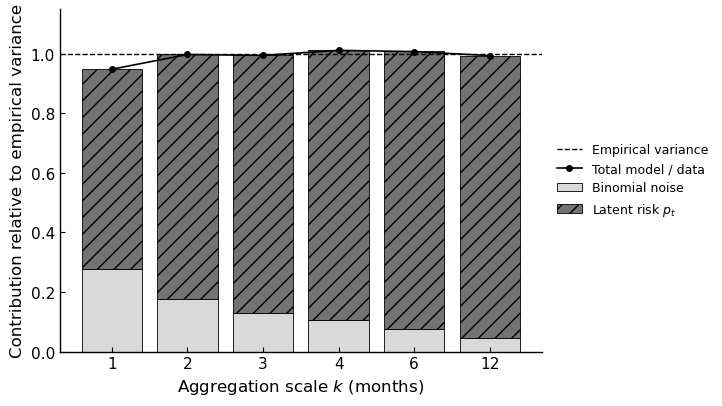

Saved: figures/figS_ou_binom_variance_decomposition_rate_over_data.pdf


In [6]:
# ============================================================
# 4a. Appendix figure: variance decomposition of monthly-equivalent default-rate variance
#
# This reproduces the figure cell in 04.ipynb whose output filename is
#   figS_ou_binom_variance_decomposition_rate_over_data.pdf
# ============================================================

# Build the same median table used by the original plotting cell.
df_kblock_decomp_median = pd.DataFrame({
    "k_month": df_rate_scaling_exact_plot["k_month"].astype(int),
    "binom_rate_over_data": df_rate_scaling_exact_plot["binom_var_over_emp_var_median"],
    "pt_rate_over_data": df_rate_scaling_exact_plot["pt_var_over_emp_var_median"],
    "total_rate_over_data": df_rate_scaling_exact_plot["model_var_over_emp_var_median"],
}).sort_values("k_month").reset_index(drop=True)

# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------
df_plot = df_kblock_decomp_median.copy()
df_plot = df_plot.sort_values("k_month").reset_index(drop=True)

k_vals = df_plot["k_month"].to_numpy()
x = np.arange(len(k_vals))

components = [
    ("binom_rate_over_data", "Binomial noise"),
    ("pt_rate_over_data", r"Latent risk $p_t$"),
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 4.2))

bottom = np.zeros(len(df_plot))

gray_levels = ["0.85", "0.45"]
hatches = ["", "//"]

for (col, label), gray, hatch in zip(components, gray_levels, hatches):
    values = df_plot[col].to_numpy(dtype=float)

    ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=gray,
        edgecolor="black",
        linewidth=0.6,
        hatch=hatch,
    )

    bottom += values

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    color="black",
    label="Empirical variance",
)

ax.plot(
    x,
    df_plot["total_rate_over_data"].to_numpy(dtype=float),
    marker="o",
    linestyle="-",
    linewidth=1.2,
    color="black",
    markersize=4,
    label="Total model / data",
)

ax.set_xticks(x)
ax.set_xticklabels(k_vals)

ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Contribution relative to empirical variance")

ymax = max(1.15, 1.08 * np.nanmax(np.r_[bottom, df_plot["total_rate_over_data"].to_numpy(dtype=float), [1.0]]))
ax.set_ylim(0.0, ymax)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=1,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0.0, 0.0, 0.78, 1.0])

fig_path = FIG_DIR / "figS_ou_binom_variance_decomposition_rate_over_data.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")


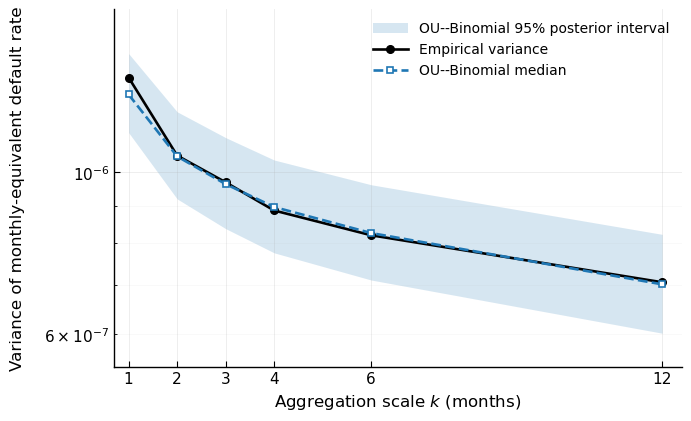

Saved:
figures/fig2_variance_monthly_equivalent_rate_scaling_survival.png
figures/fig2_variance_monthly_equivalent_rate_scaling_survival.pdf


In [7]:
# ============================================================
# Publication-quality plot:
# Variance scaling of monthly-equivalent default rate
# Black/blue version for main text Fig. 2
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
d_plot = df_rate_scaling_exact_plot.sort_values("k_month").copy()

x = d_plot["k_month"].to_numpy(dtype=float)

emp_var = d_plot["emp_var_monthly_rate_median"].to_numpy(dtype=float)

model_med = d_plot["model_var_monthly_rate_median"].to_numpy(dtype=float)
model_lo = d_plot["model_var_monthly_rate_hdi_2.5%"].to_numpy(dtype=float)
model_hi = d_plot["model_var_monthly_rate_hdi_97.5%"].to_numpy(dtype=float)

# ------------------------------------------------------------
# Color setting
# ------------------------------------------------------------
color_emp = "black"
color_model = "#1f77b4"      # clear blue
color_interval = "#1f77b4"

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(6.8, 4.1),
    constrained_layout=True,
)

# 95% posterior interval
ax.fill_between(
    x,
    model_lo,
    model_hi,
    color=color_interval,
    alpha=0.18,
    linewidth=0,
    label="OU--Binomial 95% posterior interval",
    zorder=1,
)

# Empirical variance
ax.plot(
    x,
    emp_var,
    marker="o",
    markersize=5.5,
    markerfacecolor=color_emp,
    markeredgecolor=color_emp,
    linewidth=1.9,
    linestyle="-",
    color=color_emp,
    label="Empirical variance",
    zorder=4,
)

# OU-Binomial posterior median
ax.plot(
    x,
    model_med,
    marker="s",
    markersize=5.0,
    markerfacecolor="white",
    markeredgecolor=color_model,
    markeredgewidth=1.2,
    linewidth=1.9,
    linestyle="--",
    color=color_model,
    label="OU--Binomial median",
    zorder=5,
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel(
    "Variance of monthly-equivalent default rate",
    labelpad=14,
)

ax.set_xticks([1, 2, 3, 4, 6, 12])
ax.set_xlim(0.7, 12.4)

ax.set_yscale("log")

y_min = min(np.min(emp_var), np.min(model_lo))
y_max = max(np.max(emp_var), np.max(model_hi))

ax.set_ylim(
    y_min * 0.90,
    y_max * 1.15,
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------
ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

ax.legend(
    frameon=False,
    loc="upper right",
    handlelength=2.5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig_base = FIG_DIR / f"fig2_variance_monthly_equivalent_rate_scaling_{METHOD_FOR_MAIN}"

fig.savefig(f"{fig_base}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{fig_base}.pdf", bbox_inches="tight")

plt.show()

print("Saved:")
print(f"{fig_base}.png")
print(f"{fig_base}.pdf")

## 5. Figure 2: empirical, latent, and posterior predictive ACF

In [8]:
# ============================================================
# 5. Compute ACF summaries
# ============================================================

def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return np.full(max_lag + 1, np.nan)

    x_centered = x - np.mean(x)
    var0 = np.sum(x_centered**2)
    if var0 <= 0:
        return np.full(max_lag + 1, np.nan)

    out = np.full(max_lag + 1, np.nan)
    for h in range(max_lag + 1):
        if h >= n:
            break
        out[h] = np.sum(x_centered[:n-h] * x_centered[h:]) / var0
    return out


def summarize_acf_samples(acf_samples, probs=(0.025, 0.5, 0.975)):
    acf_samples = np.asarray(acf_samples, dtype=float)
    return {
        "hdi_2.5%": np.nanquantile(acf_samples, probs[0], axis=0),
        "median": np.nanquantile(acf_samples, probs[1], axis=0),
        "hdi_97.5%": np.nanquantile(acf_samples, probs[2], axis=0),
    }


MAX_LAG_MONTHS = 36
N_ACF_SAMPLES = min(2000, p_samples.shape[0])

acf_rows_emp = []
acf_rows_latent = []
acf_rows_ppc = []
rng_acf = np.random.default_rng(SEED)

for k in K_LIST:
    df_block_k, p_block_samples_k = make_k_blocks_from_monthly(
        df_month=df_month_fit,
        p_samples=p_samples,
        k=k,
        method=METHOD_FOR_MAIN,
        drop_incomplete=True,
    )

    n_block = df_block_k["n"].to_numpy(dtype=int)
    L_block = df_block_k["L"].to_numpy(dtype=int)
    B = len(df_block_k)
    max_lag_block = min(MAX_LAG_MONTHS // k, B - 2)
    if max_lag_block < 1:
        continue

    r_emp = L_block / (n_block * k)
    acf_emp = acf_1d(r_emp, max_lag=max_lag_block)

    for lag_block in range(max_lag_block + 1):
        acf_rows_emp.append({
            "k_month": k,
            "lag_block": lag_block,
            "lag_month": k * lag_block,
            "acf_empirical": acf_emp[lag_block],
            "B": B,
        })

    S_total = p_block_samples_k.shape[0]
    sample_idx = rng_acf.choice(S_total, size=N_ACF_SAMPLES, replace=False) if S_total > N_ACF_SAMPLES else np.arange(S_total)
    p_sub = p_block_samples_k[sample_idx]

    acf_latent_samples = np.empty((len(sample_idx), max_lag_block + 1))
    acf_ppc_samples = np.empty((len(sample_idx), max_lag_block + 1))

    for i, p_k in enumerate(p_sub):
        r_latent = p_k / k
        acf_latent_samples[i] = acf_1d(r_latent, max_lag=max_lag_block)

        L_sim = rng_acf.binomial(n=n_block, p=np.clip(p_k, P_MIN, P_MAX))
        r_sim = L_sim / (n_block * k)
        acf_ppc_samples[i] = acf_1d(r_sim, max_lag=max_lag_block)

    latent_sum = summarize_acf_samples(acf_latent_samples)
    ppc_sum = summarize_acf_samples(acf_ppc_samples)

    for lag_block in range(max_lag_block + 1):
        acf_rows_latent.append({
            "k_month": k,
            "lag_block": lag_block,
            "lag_month": k * lag_block,
            "acf_hdi_2.5%": latent_sum["hdi_2.5%"][lag_block],
            "acf_median": latent_sum["median"][lag_block],
            "acf_hdi_97.5%": latent_sum["hdi_97.5%"][lag_block],
            "B": B,
            "S_used": len(sample_idx),
        })
        acf_rows_ppc.append({
            "k_month": k,
            "lag_block": lag_block,
            "lag_month": k * lag_block,
            "acf_hdi_2.5%": ppc_sum["hdi_2.5%"][lag_block],
            "acf_median": ppc_sum["median"][lag_block],
            "acf_hdi_97.5%": ppc_sum["hdi_97.5%"][lag_block],
            "B": B,
            "S_used": len(sample_idx),
        })

df_acf_emp = pd.DataFrame(acf_rows_emp)
df_acf_latent = pd.DataFrame(acf_rows_latent)
df_acf_ppc = pd.DataFrame(acf_rows_ppc)

for name, df_out in [
    ("acf_emp", df_acf_emp),
    ("acf_latent", df_acf_latent),
    ("acf_ppc", df_acf_ppc),
]:
    path = PDATA_DIR / f"ou_binom_{name}_{METHOD_FOR_MAIN}.csv"
    df_out.to_csv(path, index=False)
    print("Saved:", path)


Saved: pdata/ou_binom_acf_emp_survival.csv
Saved: pdata/ou_binom_acf_latent_survival.csv
Saved: pdata/ou_binom_acf_ppc_survival.csv


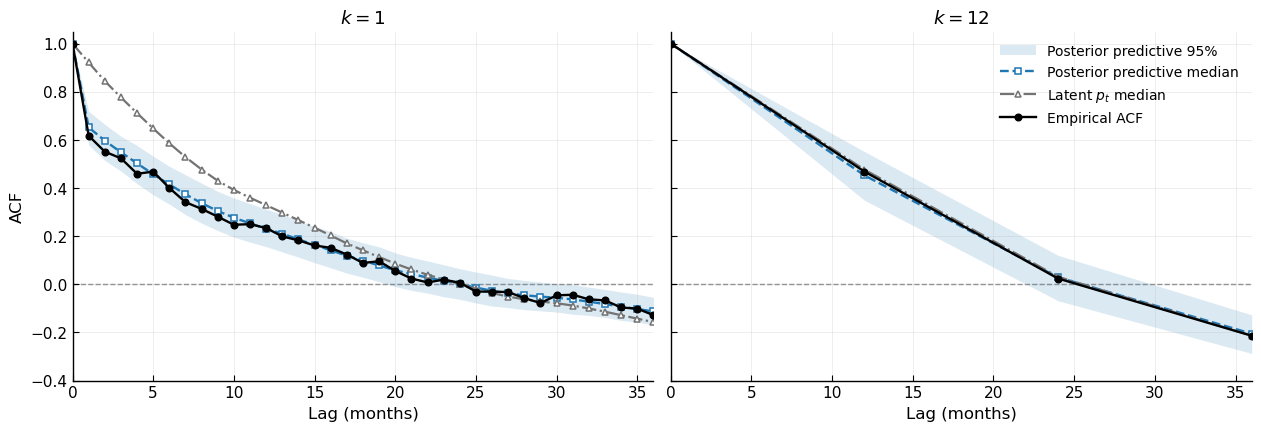

Saved: figures/fig3_ou_binom_acf_k1_k12_survival.png
Saved: figures/fig3_ou_binom_acf_k1_k12_survival.pdf


In [9]:
# ============================================================
# Plot ACF for k = 1 and k = 12 in one figure
# Black/blue version for main text Fig. 3
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

K_LIST_MAIN_ACF = [1, 12]

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Color setting
# ------------------------------------------------------------
color_emp = "black"
color_ppc = "#1f77b4"       # clear blue
color_latent = "0.45"       # gray
color_interval = "#1f77b4"
color_zero = "0.55"

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.2),
    sharey=True,
    constrained_layout=True,
)

for ax, k in zip(axes, K_LIST_MAIN_ACF):

    g_emp = df_acf_emp[df_acf_emp["k_month"] == k].copy()
    g_lat = df_acf_latent[df_acf_latent["k_month"] == k].copy()
    g_ppc = df_acf_ppc[df_acf_ppc["k_month"] == k].copy()

    # zero line
    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
        color=color_zero,
        zorder=0,
    )

    # posterior predictive interval
    ax.fill_between(
        g_ppc["lag_month"],
        g_ppc["acf_hdi_2.5%"],
        g_ppc["acf_hdi_97.5%"],
        color=color_interval,
        alpha=0.16,
        linewidth=0,
        label="Posterior predictive 95%",
        zorder=1,
    )

    # posterior predictive median
    ax.plot(
        g_ppc["lag_month"],
        g_ppc["acf_median"],
        marker="s",
        markersize=4.8,
        markerfacecolor="white",
        markeredgecolor=color_ppc,
        markeredgewidth=1.1,
        linestyle="--",
        linewidth=1.7,
        color=color_ppc,
        label="Posterior predictive median",
        zorder=3,
    )

    # latent p_t ACF
    ax.plot(
        g_lat["lag_month"],
        g_lat["acf_median"],
        marker="^",
        markersize=4.8,
        markerfacecolor="white",
        markeredgecolor=color_latent,
        markeredgewidth=1.1,
        linestyle="-.",
        linewidth=1.6,
        color=color_latent,
        label="Latent $p_t$ median",
        zorder=4,
    )

    # empirical ACF
    ax.plot(
        g_emp["lag_month"],
        g_emp["acf_empirical"],
        marker="o",
        markersize=4.8,
        markerfacecolor=color_emp,
        markeredgecolor=color_emp,
        linestyle="-",
        linewidth=1.7,
        color=color_emp,
        label="Empirical ACF",
        zorder=5,
    )

    ax.set_xlabel("Lag (months)")
    ax.set_title(f"$k = {k}$")
    ax.set_ylim(-0.4, 1.05)
    ax.set_xlim(0, 36)

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

axes[0].set_ylabel("ACF")

# legend only once
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(
    handles,
    labels,
    frameon=False,
    loc="upper right",
    handlelength=2.6,
)

# clean spines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig_path_png = FIG_DIR / f"fig3_ou_binom_acf_k1_k12_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"fig3_ou_binom_acf_k1_k12_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)

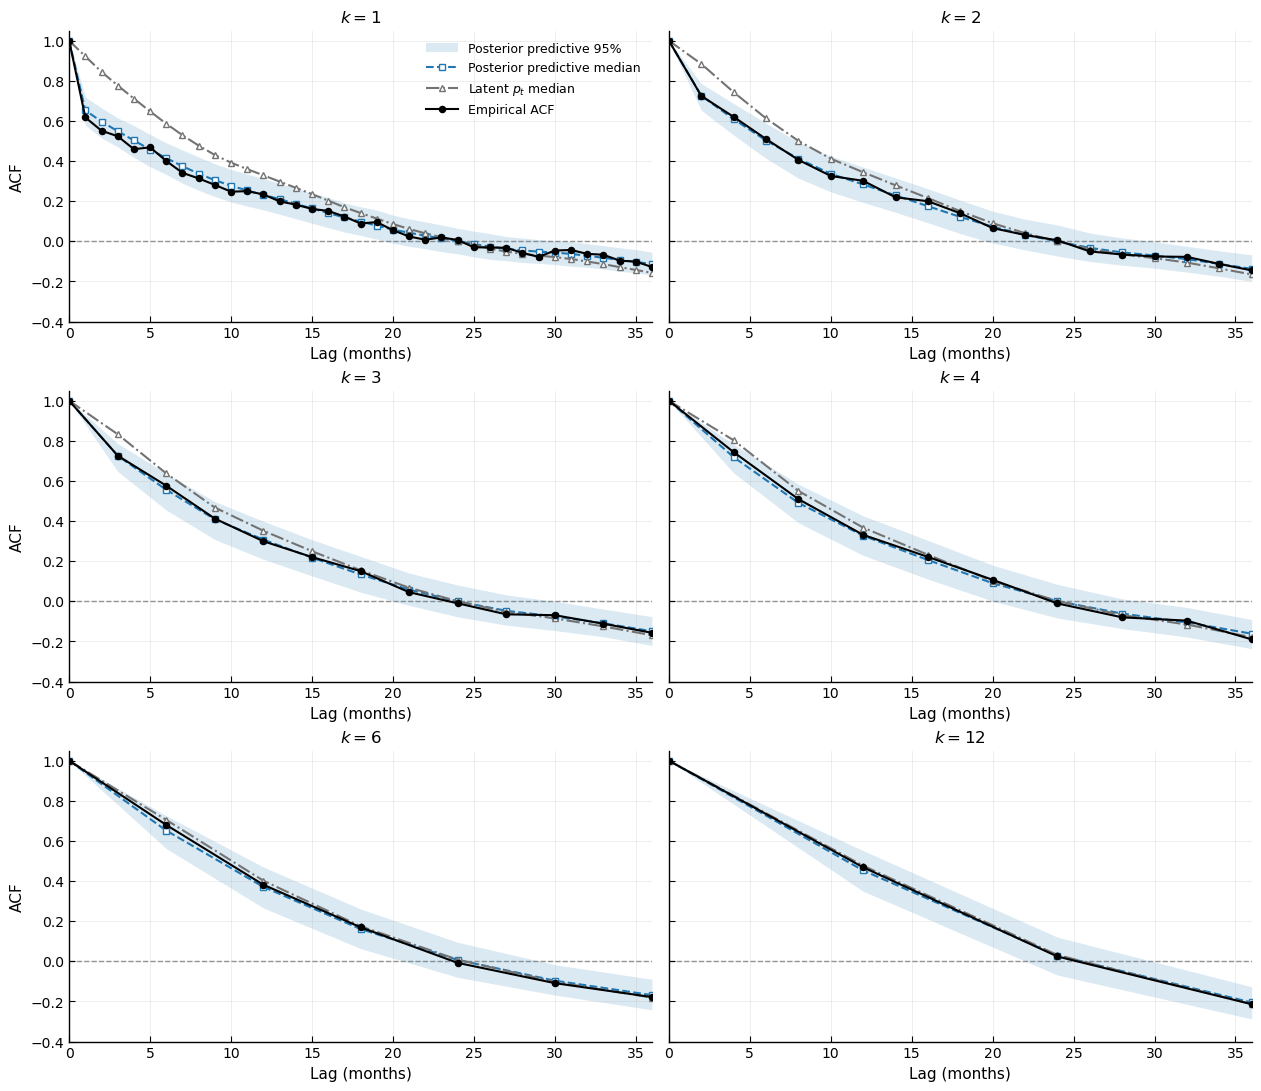

Saved: figures/figS_ou_binom_acf_appendix_k1_k2_k3_k4_k6_k12_survival.png
Saved: figures/figS_ou_binom_acf_appendix_k1_k2_k3_k4_k6_k12_survival.pdf


In [10]:
# ============================================================
# Plot ACF for k = 1, 2, 3, 4, 6, 12
# Black/blue version for appendix Fig. S
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

K_LIST_APPENDIX_ACF = [1, 2, 3, 4, 6, 12]

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Color setting
# ------------------------------------------------------------
color_emp = "black"
color_ppc = "#1f77b4"       # clear blue
color_latent = "0.45"       # gray
color_interval = "#1f77b4"
color_zero = "0.55"

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
ncols = 2
nrows = int(np.ceil(len(K_LIST_APPENDIX_ACF) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12.5, 3.6 * nrows),
    sharey=True,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, k in zip(axes, K_LIST_APPENDIX_ACF):

    g_emp = df_acf_emp[df_acf_emp["k_month"] == k].copy()
    g_lat = df_acf_latent[df_acf_latent["k_month"] == k].copy()
    g_ppc = df_acf_ppc[df_acf_ppc["k_month"] == k].copy()

    # zero line
    ax.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
        color=color_zero,
        zorder=0,
    )

    # posterior predictive interval
    ax.fill_between(
        g_ppc["lag_month"],
        g_ppc["acf_hdi_2.5%"],
        g_ppc["acf_hdi_97.5%"],
        color=color_interval,
        alpha=0.16,
        linewidth=0,
        label="Posterior predictive 95%",
        zorder=1,
    )

    # posterior predictive median
    ax.plot(
        g_ppc["lag_month"],
        g_ppc["acf_median"],
        marker="s",
        markersize=4.4,
        markerfacecolor="white",
        markeredgecolor=color_ppc,
        markeredgewidth=1.0,
        linestyle="--",
        linewidth=1.5,
        color=color_ppc,
        label="Posterior predictive median",
        zorder=3,
    )

    # latent p_t ACF
    ax.plot(
        g_lat["lag_month"],
        g_lat["acf_median"],
        marker="^",
        markersize=4.4,
        markerfacecolor="white",
        markeredgecolor=color_latent,
        markeredgewidth=1.0,
        linestyle="-.",
        linewidth=1.5,
        color=color_latent,
        label="Latent $p_t$ median",
        zorder=4,
    )

    # empirical ACF
    ax.plot(
        g_emp["lag_month"],
        g_emp["acf_empirical"],
        marker="o",
        markersize=4.4,
        markerfacecolor=color_emp,
        markeredgecolor=color_emp,
        linestyle="-",
        linewidth=1.5,
        color=color_emp,
        label="Empirical ACF",
        zorder=5,
    )

    ax.set_title(f"$k = {k}$")
    ax.set_xlabel("Lag (months)")
    ax.set_ylim(-0.4, 1.05)
    ax.set_xlim(0, 36)

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

# y-labels on left column only
for i in range(0, len(axes), ncols):
    axes[i].set_ylabel("ACF")

# remove unused axes if any
for j in range(len(K_LIST_APPENDIX_ACF), len(axes)):
    axes[j].axis("off")

# legend only in first panel
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles,
    labels,
    frameon=False,
    loc="upper right",
    handlelength=2.6,
)

# clean spines
for ax in axes[:len(K_LIST_APPENDIX_ACF)]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig_path_png = FIG_DIR / f"figS_ou_binom_acf_appendix_k1_k2_k3_k4_k6_k12_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"figS_ou_binom_acf_appendix_k1_k2_k3_k4_k6_k12_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)

## 6. Figure 3: effective mixing distributions on the probit scale

In [11]:
# ============================================================
# 6. Original vs time-shuffled coarse-grained probit distributions
# ============================================================

K_LIST_PROBIT_MAIN = [1, 3, 12]
K_LIST_PROBIT_ALL = [1, 2, 3, 4, 6, 12]
K_LABELS = {1: "Monthly", 3: "Quarterly", 12: "Annual"}


def shuffle_time_within_each_sample(p_samples, rng):
    """Preserve the marginal distribution of p_t, destroy temporal dependence."""
    p_shuffled = np.empty_like(p_samples)
    S, T = p_samples.shape
    for s in range(S):
        p_shuffled[s, :] = p_samples[s, rng.permutation(T)]
    return p_shuffled


def make_overlapping_block_p_survival_from_samples(p_samples, k):
    """Overlapping survival-type k-month block probability."""
    S, T = p_samples.shape
    B = T - k + 1
    p_block = np.empty((S, B))
    for b in range(B):
        p_seg = p_samples[:, b:b+k]
        p_block[:, b] = 1.0 - np.prod(1.0 - p_seg, axis=1)
    return np.clip(p_block, EPS, 1.0 - EPS)


def build_z_probit_df(p_samples, k_list, label):
    rows = []
    for k in k_list:
        p_block = make_overlapping_block_p_survival_from_samples(p_samples, k=k)
        z_flat = norm.ppf(p_block).ravel()
        z_flat = z_flat[np.isfinite(z_flat)]
        rows.append(pd.DataFrame({
            "k_month": k,
            "z_probit": z_flat,
            "type": label,
        }))
    return pd.concat(rows, ignore_index=True)


rng_shuffle = np.random.default_rng(SEED)
p_samples_shuffled = shuffle_time_within_each_sample(p_samples, rng_shuffle)

df_z_original_all = build_z_probit_df(p_samples, K_LIST_PROBIT_ALL, label="Original")
df_z_shuffled_all = build_z_probit_df(p_samples_shuffled, K_LIST_PROBIT_ALL, label="Time-shuffled")
df_z_all = pd.concat([df_z_original_all, df_z_shuffled_all], ignore_index=True)

rows_summary = []
for k in K_LIST_PROBIT_ALL:
    for label in ["Original", "Time-shuffled"]:
        z = df_z_all.loc[(df_z_all["k_month"] == k) & (df_z_all["type"] == label), "z_probit"].to_numpy()
        z = z[np.isfinite(z)]
        rows_summary.append({
            "k_month": k,
            "type": label,
            "n_samples": len(z),
            "mean": np.mean(z),
            "sd": np.std(z, ddof=1),
            "skewness": skew(z),
            "excess_kurtosis": kurtosis(z, fisher=True),
            "q01": np.quantile(z, 0.01),
            "q05": np.quantile(z, 0.05),
            "q50": np.quantile(z, 0.50),
            "q95": np.quantile(z, 0.95),
            "q99": np.quantile(z, 0.99),
        })

df_z_summary = pd.DataFrame(rows_summary)

z_path = PDATA_DIR / f"ou_binom_probit_original_vs_shuffled_{METHOD_FOR_MAIN}.csv"
summary_path = PDATA_DIR / f"ou_binom_probit_summary_original_vs_shuffled_{METHOD_FOR_MAIN}.csv"
df_z_all.to_csv(z_path, index=False)
df_z_summary.to_csv(summary_path, index=False)
print("Saved:", z_path)
print("Saved:", summary_path)
display(df_z_summary)


Saved: pdata/ou_binom_probit_original_vs_shuffled_survival.csv
Saved: pdata/ou_binom_probit_summary_original_vs_shuffled_survival.csv


,k_month,type,n_samples,mean,sd,skewness,excess_kurtosis,q01,q05,q50,q95,q99
0,1,Original,3912000,-3.095491,0.209054,0.249118,-0.234448,-3.530554,-3.417457,-3.113027,-2.725217,-2.598894
1,1,Time-shuffled,3912000,-3.095491,0.209054,0.249118,-0.234448,-3.530554,-3.417457,-3.113027,-2.725217,-2.598894
2,2,Original,3904000,-2.880359,0.218353,0.276354,-0.253707,-3.328248,-3.214472,-2.900641,-2.490878,-2.358581
3,2,Time-shuffled,3904000,-2.851048,0.166633,0.148068,-0.332322,-3.204825,-3.111923,-2.859013,-2.568131,-2.464273
4,3,Original,3896000,-2.747441,0.224073,0.293291,-0.276614,-3.201617,-3.089123,-2.769695,-2.345991,-2.209602
5,3,Time-shuffled,3896000,-2.706847,0.144495,0.089235,-0.312102,-3.019284,-2.937417,-2.709942,-2.464698,-2.375494
6,4,Original,3888000,-2.649374,0.228051,0.305768,-0.302434,-3.106947,-2.996193,-2.673278,-2.239226,-2.100785
7,4,Time-shuffled,3888000,-2.603089,0.130159,0.055048,-0.272053,-2.889181,-2.813654,-2.604432,-2.386547,-2.305287
8,6,Original,3872000,-2.504994,0.233198,0.321950,-0.361496,-2.964016,-2.858693,-2.531712,-2.083009,-1.947817
9,6,Time-shuffled,3872000,-2.453750,0.112002,0.020802,-0.207341,-2.705341,-2.637208,-2.454023,-2.268586,-2.197999


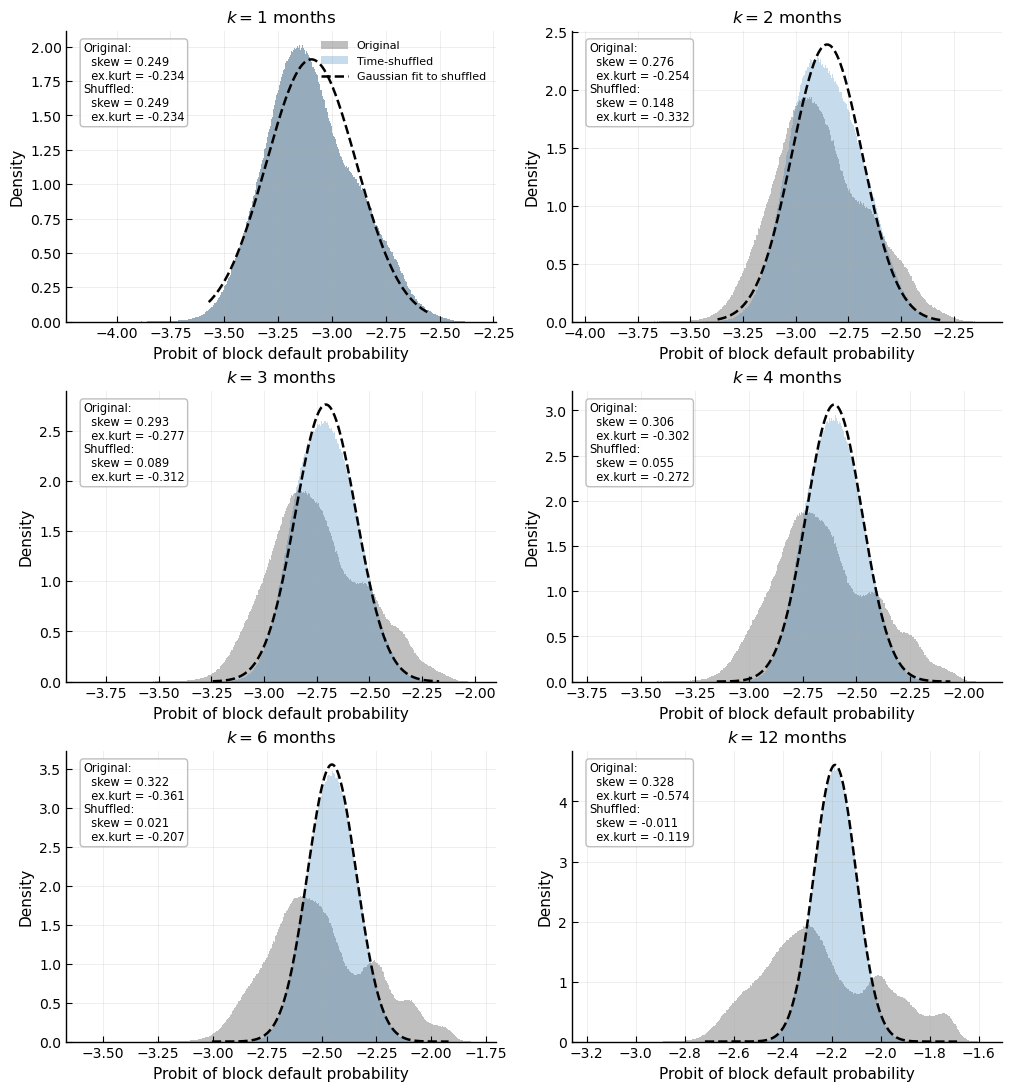

Saved: figures/figS_probit_distribution_original_vs_shuffled_k_survival.png
Saved: figures/figS_probit_distribution_original_vs_shuffled_k_survival.pdf


In [12]:
# ============================================================
# 6b. Appendix figure: original vs shuffled probit distributions for all k
#
# This reproduces the 3 x 2 appendix figure cell in 04.ipynb whose output filename is
#   figS_probit_distribution_original_vs_shuffled_k_survival.pdf
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

color_orig = "0.55"
color_shuf = "#1f77b4"
color_gauss = "black"

K_LIST_SHUFFLE = [1, 2, 3, 4, 6, 12]

# Alias matching the original 04.ipynb variable name.
df_z_compare_overlap = df_z_all.copy()
df_z_compare_overlap["type"] = df_z_compare_overlap["type"].replace({
    "Original": "original",
    "Time-shuffled": "shuffled",
})

n_cols = 2
n_rows = 3

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10.0, 10.8),
    sharey=False,
    constrained_layout=True,
)

axes = np.asarray(axes).ravel()

for idx, (ax, k) in enumerate(zip(axes, K_LIST_SHUFFLE)):

    z_orig = df_z_compare_overlap.loc[
        (df_z_compare_overlap["k_month"] == k)
        & (df_z_compare_overlap["type"] == "original"),
        "z_probit",
    ].values

    z_shuf = df_z_compare_overlap.loc[
        (df_z_compare_overlap["k_month"] == k)
        & (df_z_compare_overlap["type"] == "shuffled"),
        "z_probit",
    ].values

    z_orig = z_orig[np.isfinite(z_orig)]
    z_shuf = z_shuf[np.isfinite(z_shuf)]

    x_min = min(np.percentile(z_orig, 0.5), np.percentile(z_shuf, 0.5))
    x_max = max(np.percentile(z_orig, 99.5), np.percentile(z_shuf, 99.5))
    x_grid = np.linspace(x_min, x_max, 400)

    mu_shuf = np.mean(z_shuf)
    sd_shuf = np.std(z_shuf, ddof=1)

    ax.hist(
        z_orig,
        bins="fd",
        density=True,
        alpha=0.55,
        color=color_orig,
        edgecolor="none",
        linewidth=0.4,
        label="Original",
    )

    ax.hist(
        z_shuf,
        bins="fd",
        density=True,
        alpha=0.25,
        color=color_shuf,
        edgecolor="none",
        linewidth=0.4,
        label="Time-shuffled",
    )

    ax.plot(
        x_grid,
        norm.pdf(x_grid, loc=mu_shuf, scale=sd_shuf),
        linewidth=1.8,
        linestyle="--",
        color=color_gauss,
        label="Gaussian fit to shuffled",
    )

    text = (
        f"Original:\n"
        f"  skew = {skew(z_orig):.3f}\n"
        f"  ex.kurt = {kurtosis(z_orig, fisher=True):.3f}\n"
        f"Shuffled:\n"
        f"  skew = {skew(z_shuf):.3f}\n"
        f"  ex.kurt = {kurtosis(z_shuf, fisher=True):.3f}"
    )

    ax.text(
        0.04,
        0.96,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8.2,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.85,
        ),
    )

    ax.set_title(f"$k = {k}$ months")
    ax.set_xlabel("Probit of block default probability")
    ax.set_ylabel("Density")

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if idx == 0:
        ax.legend(
            frameon=False,
            fontsize=8,
            loc="upper right",
            handlelength=2.4,
        )

for ax in axes[len(K_LIST_SHUFFLE):]:
    ax.axis("off")

fig_path_png = FIG_DIR / f"figS_probit_distribution_original_vs_shuffled_k_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"figS_probit_distribution_original_vs_shuffled_k_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)


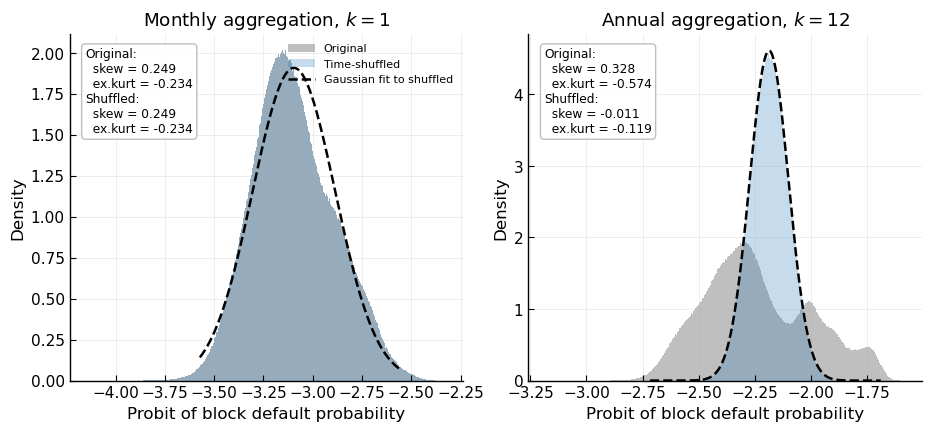

Saved: figures/fig4_probit_distribution_original_vs_shuffled_k1_k12_survival.png
Saved: figures/fig4_probit_distribution_original_vs_shuffled_k1_k12_survival.pdf


In [13]:
# ============================================================
# 6c. Main-text figure: original vs shuffled probit distributions, k = 1 and 12
#
# This reproduces the Fig. 4 cell in 04.ipynb whose output filename is
#   fig4_probit_distribution_original_vs_shuffled_k1_k12_survival.pdf
# ============================================================

K_LIST_MAIN = [1, 12]
K_LABELS_MAIN = {1: "Monthly", 12: "Annual"}

# Alias matching the original 04.ipynb variable name.
df_z_plot = df_z_all.copy()

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

color_orig = "0.55"
color_shuf = "#1f77b4"
color_gauss = "black"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.2),
    sharey=False,
    constrained_layout=True,
)

for idx, (ax, k) in enumerate(zip(axes, K_LIST_MAIN)):

    z_orig = df_z_plot.loc[
        (df_z_plot["k_month"] == k)
        & (df_z_plot["type"] == "Original"),
        "z_probit",
    ].values

    z_shuf = df_z_plot.loc[
        (df_z_plot["k_month"] == k)
        & (df_z_plot["type"] == "Time-shuffled"),
        "z_probit",
    ].values

    z_orig = z_orig[np.isfinite(z_orig)]
    z_shuf = z_shuf[np.isfinite(z_shuf)]

    x_min = min(np.percentile(z_orig, 0.5), np.percentile(z_shuf, 0.5))
    x_max = max(np.percentile(z_orig, 99.5), np.percentile(z_shuf, 99.5))
    x_grid = np.linspace(x_min, x_max, 400)

    mu_shuf = np.mean(z_shuf)
    sd_shuf = np.std(z_shuf, ddof=1)

    ax.hist(
        z_orig,
        bins="fd",
        density=True,
        alpha=0.55,
        color=color_orig,
        edgecolor="none",
        linewidth=0.4,
        label="Original",
    )

    ax.hist(
        z_shuf,
        bins="fd",
        density=True,
        alpha=0.25,
        color=color_shuf,
        edgecolor="none",
        linewidth=0.4,
        label="Time-shuffled",
    )

    ax.plot(
        x_grid,
        norm.pdf(x_grid, loc=mu_shuf, scale=sd_shuf),
        linestyle="--",
        linewidth=1.8,
        color=color_gauss,
        label="Gaussian fit to shuffled",
    )

    skew_orig = skew(z_orig)
    kurt_orig = kurtosis(z_orig, fisher=True)
    skew_shuf = skew(z_shuf)
    kurt_shuf = kurtosis(z_shuf, fisher=True)

    text = (
        f"Original:\n"
        f"  skew = {skew_orig:.3f}\n"
        f"  ex.kurt = {kurt_orig:.3f}\n"
        f"Shuffled:\n"
        f"  skew = {skew_shuf:.3f}\n"
        f"  ex.kurt = {kurt_shuf:.3f}"
    )

    ax.text(
        0.04,
        0.96,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8.8,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.85,
        ),
    )

    ax.set_title(f"{K_LABELS_MAIN[k]} aggregation, $k = {k}$")
    ax.set_xlabel("Probit of block default probability")
    ax.set_ylabel("Density")

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if idx == 0:
        ax.legend(
            frameon=False,
            fontsize=8,
            loc="upper right",
            handlelength=2.4,
        )

fig_path_png = FIG_DIR / f"fig4_probit_distribution_original_vs_shuffled_k1_k12_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"fig4_probit_distribution_original_vs_shuffled_k1_k12_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)


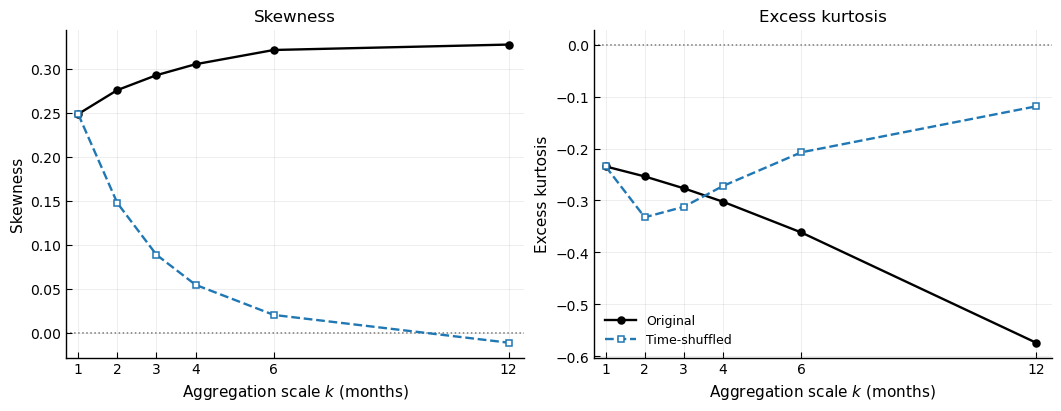

Saved: figures/figS_skewness_excess_kurtosis_vs_k_survival.png
Saved: figures/figS_skewness_excess_kurtosis_vs_k_survival.pdf


In [14]:
# ============================================================
# 6d. Appendix figure: skewness and excess kurtosis vs k
#
# This reproduces the appendix figure cell in 04.ipynb whose output filename is
#   figS_skewness_excess_kurtosis_vs_k_survival.pdf
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

style_dict = {
    "Original": {
        "label": "Original",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
    },
    "Time-shuffled": {
        "label": "Time-shuffled",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
        "markeredgecolor": "#1f77b4",
    },
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.0),
    constrained_layout=True,
)

for label in ["Original", "Time-shuffled"]:

    d = (
        df_z_summary[df_z_summary["type"] == label]
        .sort_values("k_month")
        .copy()
    )

    st = style_dict[label]

    axes[0].plot(
        d["k_month"],
        d["skewness"],
        marker=st["marker"],
        markersize=5.0,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["markeredgecolor"],
        markeredgewidth=1.1,
        linestyle=st["linestyle"],
        linewidth=1.7,
        color=st["color"],
        label=st["label"],
    )

    axes[1].plot(
        d["k_month"],
        d["excess_kurtosis"],
        marker=st["marker"],
        markersize=5.0,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["markeredgecolor"],
        markeredgewidth=1.1,
        linestyle=st["linestyle"],
        linewidth=1.7,
        color=st["color"],
        label=st["label"],
    )

for ax in axes:
    ax.axhline(
        0.0,
        linestyle=":",
        linewidth=1.1,
        color="0.45",
        zorder=0,
    )

    ax.set_xlabel("Aggregation scale $k$ (months)")
    ax.set_xticks([1, 2, 3, 4, 6, 12])
    ax.set_xlim(0.7, 12.4)

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Skewness")
axes[0].set_title("Skewness")

axes[1].set_ylabel("Excess kurtosis")
axes[1].set_title("Excess kurtosis")

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(
    handles,
    labels,
    frameon=False,
    loc="best",
    handlelength=2.5,
)

fig_path_png = FIG_DIR / f"figS_skewness_excess_kurtosis_vs_k_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"figS_skewness_excess_kurtosis_vs_k_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)


,k_month,B,pbar_k_median,pbar_k_hdi_2.5%,pbar_k_hdi_97.5%,var_Gk_median,var_Gk_hdi_2.5%,var_Gk_hdi_97.5%,rho_default_eff_median,rho_default_eff_hdi_2.5%,rho_default_eff_hdi_97.5%,rho_asset_implied_median,rho_asset_implied_hdi_2.5%,rho_asset_implied_hdi_97.5%
0,1,489,0.001233,0.001180,0.001286,9.033445e-07,7.664769e-07,0.000001,0.000736,0.000630,0.000854,0.044422,0.039095,0.050118
1,2,244,0.002466,0.002360,0.002572,3.454351e-06,2.942749e-06,0.000004,0.001409,0.001209,0.001632,0.048675,0.042692,0.054978
2,3,163,0.003691,0.003533,0.003850,7.547774e-06,6.420131e-06,0.000009,0.002058,0.001764,0.002388,0.051781,0.045469,0.058660
3,4,122,0.004923,0.004711,0.005134,1.282980e-05,1.093884e-05,0.000015,0.002622,0.002262,0.003048,0.053053,0.046680,0.060088
4,6,81,0.007385,0.007069,0.007706,2.748056e-05,2.339110e-05,0.000032,0.003751,0.003220,0.004362,0.055946,0.049120,0.063136
5,12,40,0.014727,0.014102,0.015377,9.661896e-05,8.220214e-05,0.000114,0.006662,0.005720,0.007730,0.060442,0.052755,0.068822


Saved:
pdata/effective_correlations_from_Gk_samples_survival.csv
pdata/effective_correlations_from_Gk_summary_survival.csv


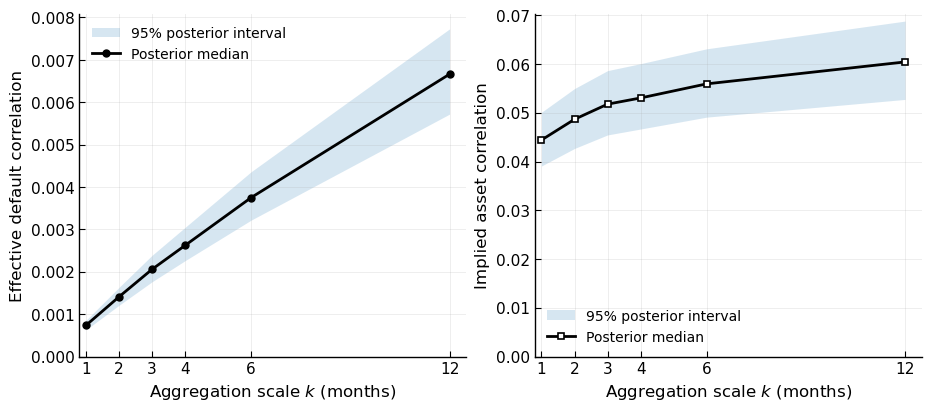

Saved:
figures/figS_effective_default_and_asset_correlation_from_Gk_survival.png
figures/figS_effective_default_and_asset_correlation_from_Gk_survival.pdf


In [15]:
# ============================================================
# Effective default correlation and implied asset correlation
# from the renormalized mixing distribution G_k(p)
#
# Definition:
#   p ~ G_k(p)
#   rho_D(k) = Var_Gk(p) / [pbar_k * (1 - pbar_k)]
#
# Here pbar_k is taken as the k-month average default probability,
# i.e. k times the one-month default probability.
#
# The asset correlation rho_A(k) is defined as the Vasicek asset
# correlation that reproduces rho_D(k) at default probability pbar_k:
#
#   rho_D = [Phi_2(a, a; rho_A) - pbar_k^2] / [pbar_k(1-pbar_k)],
#   a = Phi^{-1}(pbar_k).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, multivariate_normal
from scipy.optimize import brentq

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

K_LIST_CORR = [1, 2, 3, 4, 6, 12]

# Use the convention requested:
#   pbar_k = k * one-month default probability
#
# Alternative:
#   DEFAULT_PROB_MODE = "mean_Gk"
# uses pbar_k = E_{G_k}[p].
#DEFAULT_PROB_MODE = "k_times_monthly_mean"
DEFAULT_PROB_MODE = "mean_Gk"

# To reduce computation for the Vasicek inversion if necessary.
# Set to None to use all posterior samples.
MAX_POSTERIOR_SAMPLES_FOR_CORR = 2000

rng_corr = np.random.default_rng(SEED)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def vasicek_default_corr_from_asset_corr(p_default, rho_A):
    """
    Observable pairwise default correlation implied by the Vasicek model.

    Parameters
    ----------
    p_default : float
        Default probability over the relevant horizon.
    rho_A : float
        Asset correlation.

    Returns
    -------
    rho_D : float
        Pairwise default correlation.
    """
    p_default = float(np.clip(p_default, P_MIN, P_MAX))
    rho_A = float(np.clip(rho_A, 0.0, 1.0 - 1e-12))

    if rho_A <= 0.0:
        return 0.0

    a = norm.ppf(p_default)

    cov = np.array([
        [1.0, rho_A],
        [rho_A, 1.0],
    ])

    joint = multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov)
    rho_D = (joint - p_default**2) / (p_default * (1.0 - p_default))

    return float(rho_D)


def implied_asset_corr_from_default_corr(p_default, rho_D_target):
    """
    Solve for the Vasicek asset correlation rho_A that reproduces
    the target default correlation rho_D_target.

    Returns NaN if the target is outside the numerically attainable range.
    """
    p_default = float(np.clip(p_default, P_MIN, P_MAX))
    rho_D_target = float(rho_D_target)

    if not np.isfinite(rho_D_target):
        return np.nan

    if rho_D_target <= 0.0:
        return 0.0

    # Maximum attainable default correlation is approached as rho_A -> 1.
    rho_D_max = vasicek_default_corr_from_asset_corr(p_default, 1.0 - 1e-8)

    if rho_D_target >= rho_D_max:
        return 1.0

    def f(rho_A):
        return vasicek_default_corr_from_asset_corr(p_default, rho_A) - rho_D_target

    try:
        return brentq(f, 0.0, 1.0 - 1e-8, xtol=1e-10, rtol=1e-10, maxiter=100)
    except Exception:
        return np.nan


def summarize_array(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "median": np.nan,
            "hdi_2.5%": np.nan,
            "hdi_97.5%": np.nan,
        }

    return {
        "median": np.quantile(x, 0.50),
        "hdi_2.5%": np.quantile(x, 0.025),
        "hdi_97.5%": np.quantile(x, 0.975),
    }


# ------------------------------------------------------------
# Main calculation
# ------------------------------------------------------------

rows_sample = []

S_total = p_samples.shape[0]

if MAX_POSTERIOR_SAMPLES_FOR_CORR is not None and S_total > MAX_POSTERIOR_SAMPLES_FOR_CORR:
    sample_ids = rng_corr.choice(
        np.arange(S_total),
        size=MAX_POSTERIOR_SAMPLES_FOR_CORR,
        replace=False,
    )
    sample_ids = np.sort(sample_ids)
else:
    sample_ids = np.arange(S_total)

p_samples_corr = p_samples[sample_ids, :]

for k in K_LIST_CORR:

    df_block_k, p_block_samples_k = make_k_blocks_from_monthly(
        df_month=df_month_fit,
        p_samples=p_samples_corr,
        k=k,
        method=METHOD_FOR_MAIN,
        drop_incomplete=True,
    )

    # p_block_samples_k has shape:
    #   posterior sample x block
    #
    # This is the empirical posterior representation of G_k(p).
    p_block_samples_k = np.clip(p_block_samples_k, P_MIN, P_MAX)

    S_use, B_k = p_block_samples_k.shape

    for s in range(S_use):

        p_g = p_block_samples_k[s, :]

        # Variance of the effective mixing distribution G_k(p)
        var_Gk = np.var(p_g, ddof=1)

        # Default probability over k months.
        #
        # User convention:
        #   pbar_k = k * one-month default probability.
        #
        # This is close to the survival-aggregated mean when probabilities are small.
        if DEFAULT_PROB_MODE == "k_times_monthly_mean":
            pbar_1m = np.mean(p_samples_corr[s, :])
            pbar_k = k * pbar_1m
        elif DEFAULT_PROB_MODE == "mean_Gk":
            pbar_k = np.mean(p_g)
        else:
            raise ValueError("DEFAULT_PROB_MODE must be 'k_times_monthly_mean' or 'mean_Gk'.")

        pbar_k = float(np.clip(pbar_k, P_MIN, P_MAX))

        # Effective pairwise default correlation generated by G_k(p)
        rho_D_eff = var_Gk / (pbar_k * (1.0 - pbar_k))

        # Numerical guard
        rho_D_eff = float(np.clip(rho_D_eff, 0.0, 1.0))

        # Implied Vasicek asset correlation
        rho_A_eff = implied_asset_corr_from_default_corr(
            p_default=pbar_k,
            rho_D_target=rho_D_eff,
        )

        rows_sample.append({
            "k_month": k,
            "sample": int(sample_ids[s]),
            "B": B_k,
            "pbar_k": pbar_k,
            "var_Gk": var_Gk,
            "rho_default_eff": rho_D_eff,
            "rho_asset_implied": rho_A_eff,
        })

df_corr_Gk_samples = pd.DataFrame(rows_sample)


# ------------------------------------------------------------
# Posterior summaries
# ------------------------------------------------------------

rows_summary = []

for k, g in df_corr_Gk_samples.groupby("k_month"):

    row = {
        "k_month": int(k),
        "B": int(g["B"].iloc[0]),
    }

    for col in [
        "pbar_k",
        "var_Gk",
        "rho_default_eff",
        "rho_asset_implied",
    ]:
        q = summarize_array(g[col].to_numpy())
        row[f"{col}_median"] = q["median"]
        row[f"{col}_hdi_2.5%"] = q["hdi_2.5%"]
        row[f"{col}_hdi_97.5%"] = q["hdi_97.5%"]

    rows_summary.append(row)

df_corr_Gk_summary = pd.DataFrame(rows_summary).sort_values("k_month").reset_index(drop=True)

display(df_corr_Gk_summary)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

out_sample_path = PDATA_DIR / f"effective_correlations_from_Gk_samples_{METHOD_FOR_MAIN}.csv"
out_summary_path = PDATA_DIR / f"effective_correlations_from_Gk_summary_{METHOD_FOR_MAIN}.csv"

df_corr_Gk_samples.to_csv(out_sample_path, index=False)
df_corr_Gk_summary.to_csv(out_summary_path, index=False)

print("Saved:")
print(out_sample_path)
print(out_summary_path)


# ============================================================
# Plot: effective default correlation and implied asset correlation
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

d = df_corr_Gk_summary.copy()

x = d["k_month"].to_numpy(dtype=float)

rhoD_med = d["rho_default_eff_median"].to_numpy(dtype=float)
rhoD_lo = d["rho_default_eff_hdi_2.5%"].to_numpy(dtype=float)
rhoD_hi = d["rho_default_eff_hdi_97.5%"].to_numpy(dtype=float)

rhoA_med = d["rho_asset_implied_median"].to_numpy(dtype=float)
rhoA_lo = d["rho_asset_implied_hdi_2.5%"].to_numpy(dtype=float)
rhoA_hi = d["rho_asset_implied_hdi_97.5%"].to_numpy(dtype=float)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.0),
    constrained_layout=True,
)

# ------------------------------------------------------------
# Left: effective default correlation
# ------------------------------------------------------------

ax = axes[0]

ax.fill_between(
    x,
    rhoD_lo,
    rhoD_hi,
    color="#1f77b4",
    alpha=0.18,
    linewidth=0.0,
    label="95% posterior interval",
)

ax.plot(
    x,
    rhoD_med,
    color="black",
    linestyle="-",
    linewidth=2.0,
    marker="o",
    markersize=5.0,
    markerfacecolor="black",
    markeredgecolor="black",
    label="Posterior median",
)

ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Effective default correlation")
ax.set_xticks(K_LIST_CORR)
ax.set_xlim(0.8, max(K_LIST_CORR) + 0.5)
ax.set_ylim(bottom=0.0)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="best")


# ------------------------------------------------------------
# Right: implied Vasicek asset correlation
# ------------------------------------------------------------

ax = axes[1]

ax.fill_between(
    x,
    rhoA_lo,
    rhoA_hi,
    color="#1f77b4",
    alpha=0.18,
    linewidth=0.0,
    label="95% posterior interval",
)

ax.plot(
    x,
    rhoA_med,
    color="black",
    linestyle="-",
    linewidth=2.0,
    marker="s",
    markersize=5.0,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=1.2,
    label="Posterior median",
)

ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Implied asset correlation")
ax.set_xticks(K_LIST_CORR)
ax.set_xlim(0.8, max(K_LIST_CORR) + 0.5)
ax.set_ylim(bottom=0.0)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="best")


fig_path_png = FIG_DIR / f"figS_effective_default_and_asset_correlation_from_Gk_{METHOD_FOR_MAIN}.png"
fig_path_pdf = FIG_DIR / f"figS_effective_default_and_asset_correlation_from_Gk_{METHOD_FOR_MAIN}.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(fig_path_png)
print(fig_path_pdf)
